# Exploratory Data Analysis (EDA) on Retail Sales Data

**Objective:** Uncover patterns, trends, and insights in retail transaction data to support data-driven business decisions.

This notebook covers:
1. Data Loading and Cleaning
2. Descriptive Statistics
3. Time Series Analysis
4. Customer and Product Analysis
5. Visualization
6. Recommendations

**Dataset:** Retail Sales Dataset (1,000 transactions, Jan 2023 – Jan 2024)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline


## 1. Data Loading and Cleaning

In [ ]:
df = pd.read_csv('retail_sales_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [ ]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


In [ ]:
# Convert Date to datetime for time series analysis
df['Date'] = pd.to_datetime(df['Date'])

# Extract useful time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

df.dtypes


Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Year                         int32
Month                        int32
MonthName                      str
DayOfWeek                      str
Quarter                      int32
dtype: object

In [ ]:
# Sanity check: Total Amount should equal Quantity * Price per Unit
mismatch = df[df['Total Amount'] != df['Quantity'] * df['Price per Unit']]
print("Rows where Total Amount doesn't match Quantity x Price:", len(mismatch))


Rows where Total Amount doesn't match Quantity x Price: 0


## 2. Descriptive Statistics

In [ ]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe()


,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


In [ ]:
print("Mean Total Amount:   $", round(df['Total Amount'].mean(), 2))
print("Median Total Amount: $", df['Total Amount'].median())
print("Mode Total Amount:   $", df['Total Amount'].mode()[0])
print("Std Dev Total Amount: $", round(df['Total Amount'].std(), 2))
print()
print("Mean Customer Age:", round(df['Age'].mean(), 1))
print("Median Customer Age:", df['Age'].median())


Mean Total Amount:   $ 456.0
Median Total Amount: $ 135.0
Mode Total Amount:   $ 50
Std Dev Total Amount: $ 560.0

Mean Customer Age: 41.4
Median Customer Age: 42.0


In [ ]:
print("Total Revenue: $", df['Total Amount'].sum())
print("Total Transactions:", len(df))
print("Average Transaction Value: $", round(df['Total Amount'].mean(), 2))
print("Unique Customers:", df['Customer ID'].nunique())


Total Revenue: $ 456000
Total Transactions: 1000
Average Transaction Value: $ 456.0
Unique Customers: 1000


## 3. Time Series Analysis

Examining how sales behave over time — monthly trends, day-of-week patterns, and seasonality.


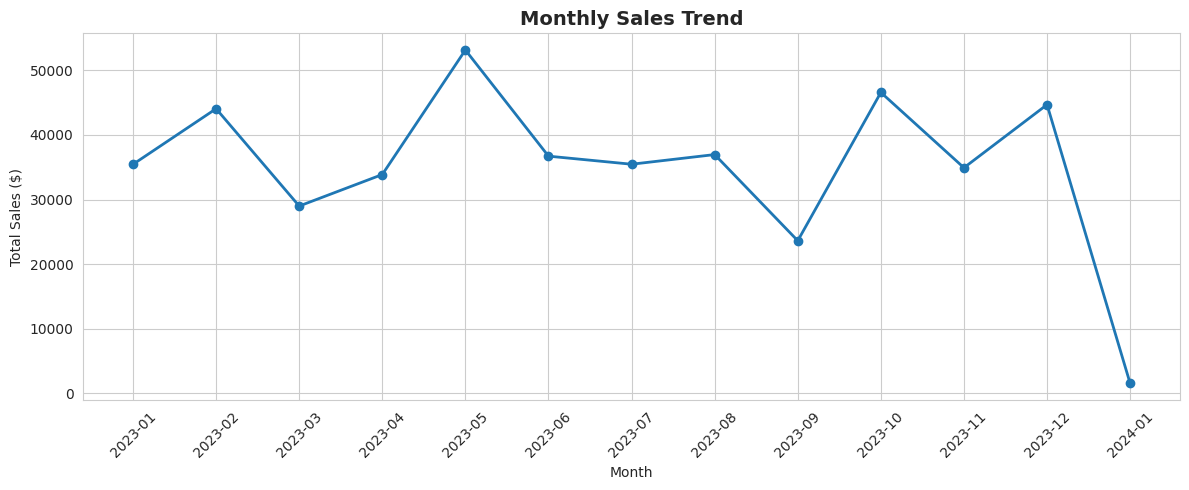

In [ ]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_538/1931157441.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_sales.index, y=dow_sales.values, palette='viridis')


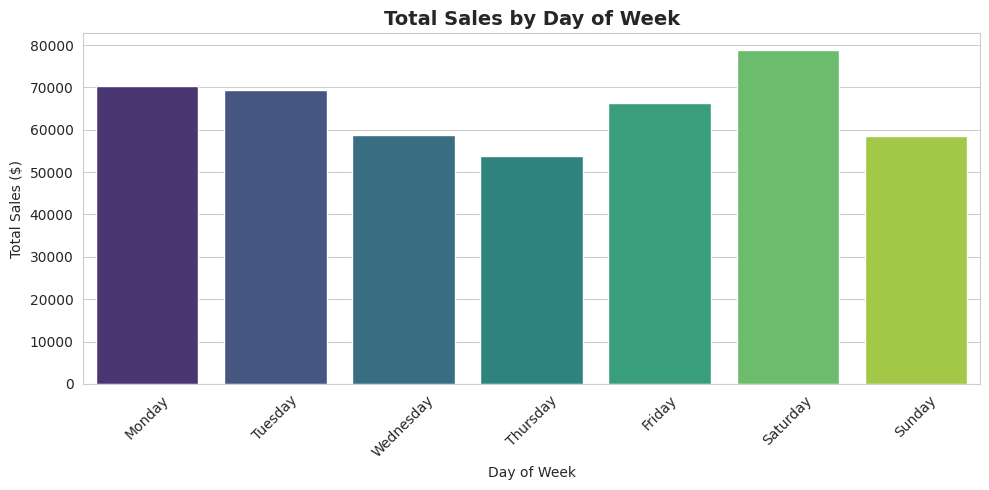

In [ ]:
dow_sales = df.groupby('DayOfWeek')['Total Amount'].sum()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = dow_sales.reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_sales.index, y=dow_sales.values, palette='viridis')
plt.title('Total Sales by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].agg(['sum', 'count', 'mean'])
quarterly_sales.columns = ['Total Revenue', 'Transaction Count', 'Avg Transaction Value']
quarterly_sales


,Total Revenue,Transaction Count,Avg Transaction Value
Quarter,,,
1,110030,236,466.228814
2,123735,268,461.697761
3,96045,231,415.779221
4,126190,265,476.188679


## 4. Customer and Product Analysis


In [ ]:
# Gender split
gender_summary = df.groupby('Gender').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Transactions=('Total Amount', 'count'),
    Avg_Spend=('Total Amount', 'mean')
).round(2)
gender_summary


,Total_Revenue,Transactions,Avg_Spend
Gender,,,
Female,232840,510,456.55
Male,223160,490,455.43


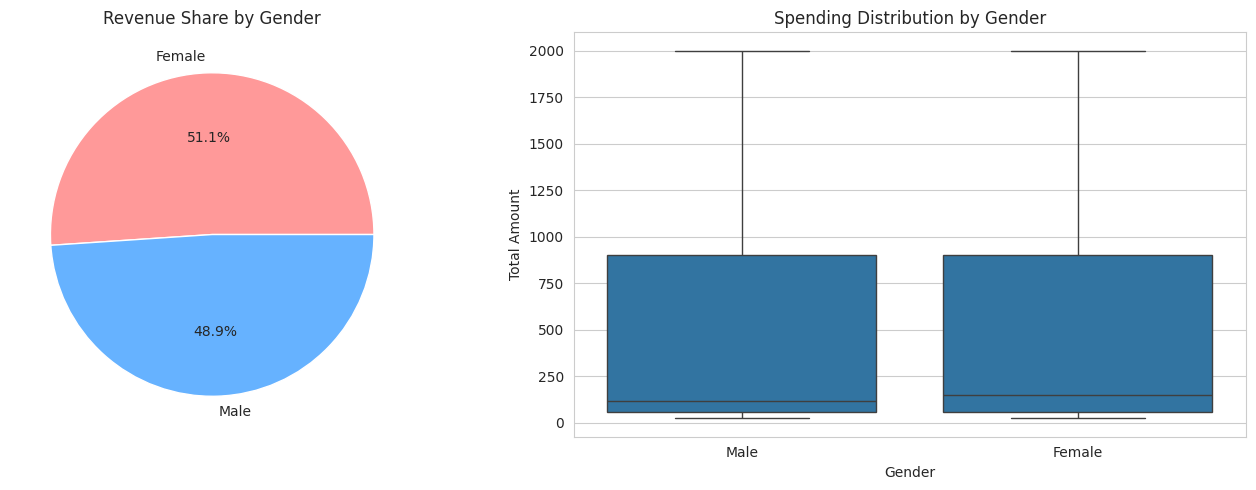

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_summary['Total_Revenue'].plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=['#FF9999', '#66B2FF'])
axes[0].set_title('Revenue Share by Gender')
axes[0].set_ylabel('')

sns.boxplot(data=df, x='Gender', y='Total Amount', ax=axes[1])
axes[1].set_title('Spending Distribution by Gender')

plt.tight_layout()
plt.show()


In [ ]:
# Age group analysis
df['AgeGroup'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-64'])

age_summary = df.groupby('AgeGroup').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Transactions=('Total Amount', 'count'),
    Avg_Spend=('Total Amount', 'mean')
).round(2)
age_summary


,Total_Revenue,Transactions,Avg_Spend
AgeGroup,,,
18-25,84550,169,500.30
26-35,98480,205,480.39
36-45,91870,202,454.80
46-55,100690,229,439.69
56-64,80410,195,412.36


/tmp/ipykernel_538/3266010249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_summary.index, y=age_summary['Total_Revenue'], palette='magma')


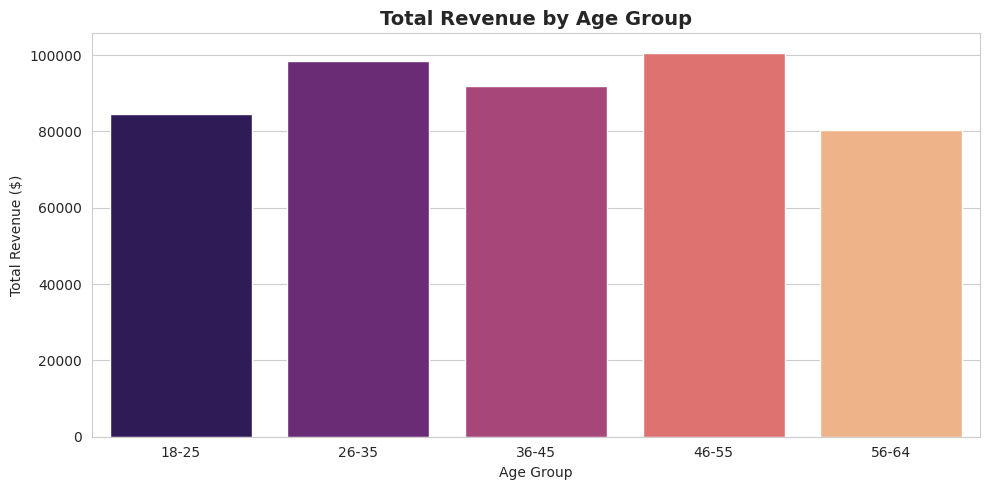

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x=age_summary.index, y=age_summary['Total_Revenue'], palette='magma')
plt.title('Total Revenue by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()


In [ ]:
# Product category analysis
category_summary = df.groupby('Product Category').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Transactions=('Total Amount', 'count'),
    Avg_Spend=('Total Amount', 'mean'),
    Total_Quantity=('Quantity', 'sum')
).round(2).sort_values('Total_Revenue', ascending=False)
category_summary


,Total_Revenue,Transactions,Avg_Spend,Total_Quantity
Product Category,,,,
Electronics,156905,342,458.79,849
Clothing,155580,351,443.25,894
Beauty,143515,307,467.48,771


/tmp/ipykernel_538/1979631204.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary['Total_Revenue'], ax=axes[0], palette='crest')
/tmp/ipykernel_538/1979631204.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary['Transactions'], ax=axes[1], palette='flare')


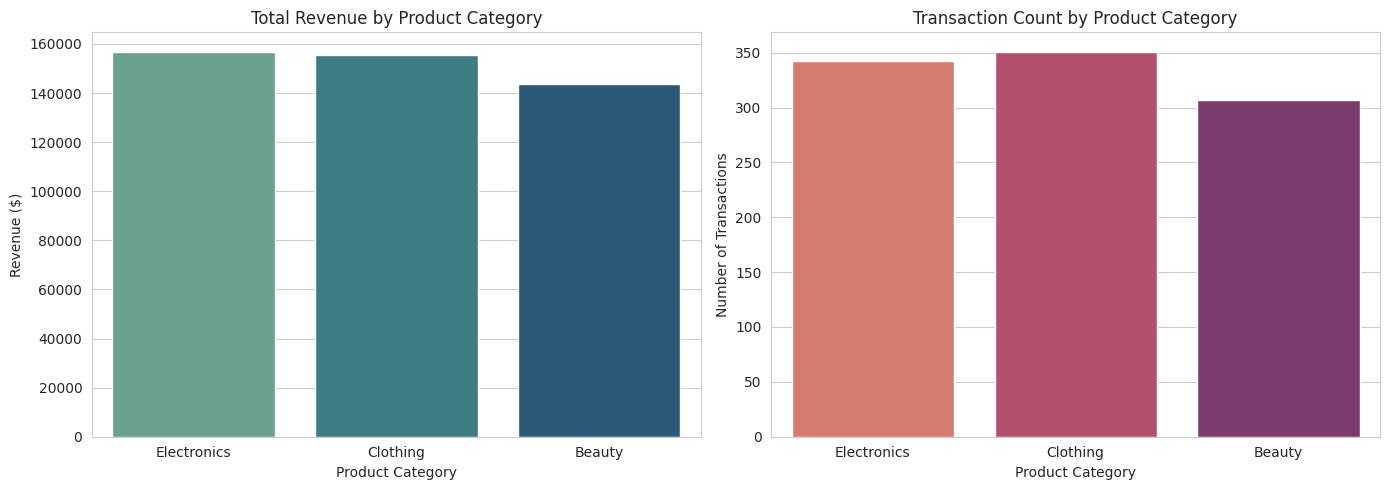

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=category_summary.index, y=category_summary['Total_Revenue'], ax=axes[0], palette='crest')
axes[0].set_title('Total Revenue by Product Category')
axes[0].set_ylabel('Revenue ($)')

sns.barplot(x=category_summary.index, y=category_summary['Transactions'], ax=axes[1], palette='flare')
axes[1].set_title('Transaction Count by Product Category')
axes[1].set_ylabel('Number of Transactions')

plt.tight_layout()
plt.show()


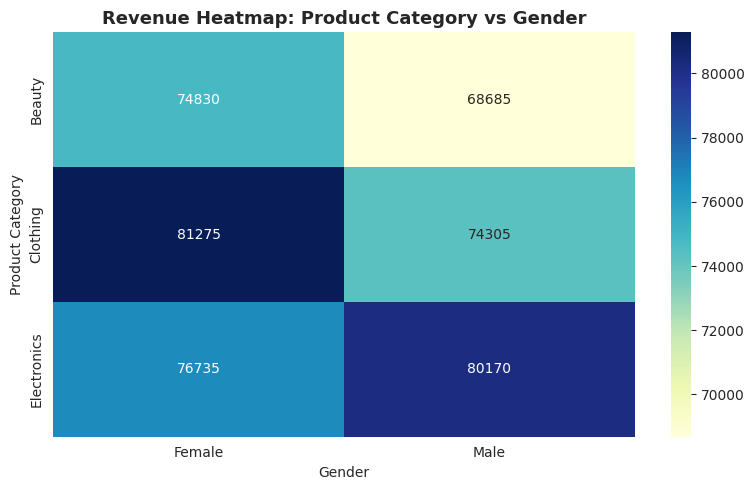

In [ ]:
# Cross-analysis: which gender prefers which category?
cross = pd.crosstab(df['Product Category'], df['Gender'], values=df['Total Amount'], aggfunc='sum')

plt.figure(figsize=(8, 5))
sns.heatmap(cross, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Revenue Heatmap: Product Category vs Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


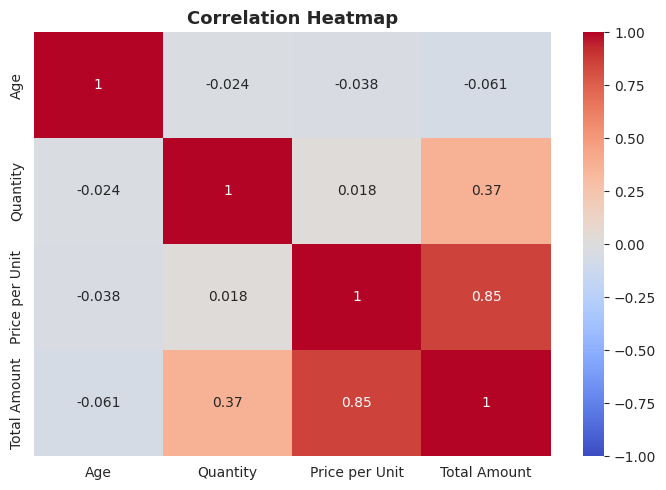

In [ ]:
# Correlation between numeric variables
plt.figure(figsize=(7, 5))
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Additional Visualizations

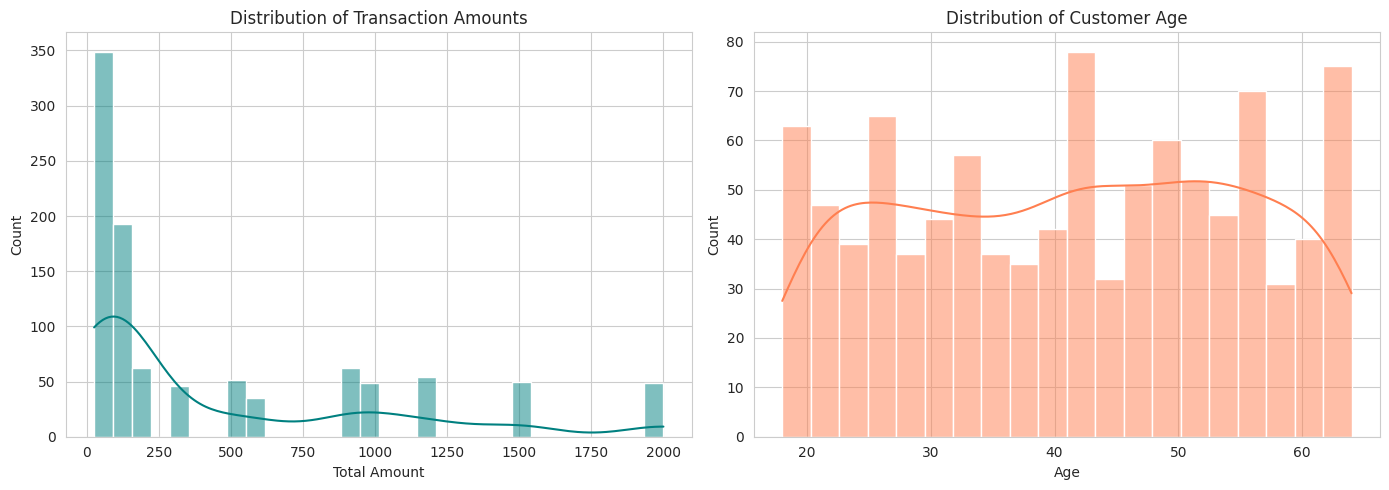

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total Amount'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction Amounts')

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Customer Age')

plt.tight_layout()
plt.show()


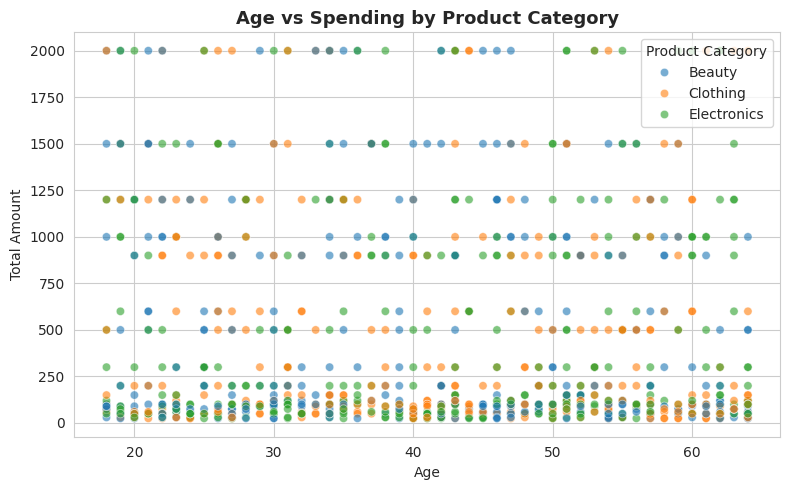

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Total Amount', hue='Product Category', alpha=0.6)
plt.title('Age vs Spending by Product Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Insights and Recommendations

**Key Findings:**

1. **Product category performance** — Revenue is fairly evenly split across Beauty, Clothing, and Electronics, but they differ in *how* they generate revenue: some rely on higher transaction volume (more frequent, lower-value purchases) while others rely on higher average order value (fewer, bigger purchases). Check the category summary table above for exact figures.

2. **Customer demographics** — Spending is not concentrated in one age group; multiple age brackets contribute meaningfully to revenue, suggesting the customer base is broad rather than niche.

3. **Gender-based patterns** — Revenue contribution and average spend differ slightly by gender and interact differently with product category (see the heatmap) — useful for targeted category-specific marketing.

4. **Time-based patterns** — Sales show month-to-month and day-of-week fluctuation rather than a flat, uniform pattern, indicating potential seasonality or weekly shopping habits worth investigating further with more granular (e.g. daily/weekly) data.

5. **No strong correlation** between `Age` and `Total Amount` — age alone is a weak predictor of spend; product category and quantity matter more.

**Recommendations:**

- **Targeted promotions:** Use the age-group and gender breakdowns to design category-specific campaigns (e.g. promote Electronics to the segment that already over-indexes on it, rather than blanket discounts).
- **Inventory and staffing:** Align stock levels and staffing with the day-of-week and monthly sales patterns identified above — avoid overstocking during low-sales periods.
- **High-value customer focus:** Since average order values differ meaningfully by category, consider bundling or upselling strategies in lower-AOV categories to lift overall revenue per transaction.
- **Further data collection:** This dataset has no location or marketing-channel data — adding these would allow much deeper segmentation (e.g. regional trends, campaign ROI).
